In [1]:
import torch
from splice import _LocWrapper  # needed for unpickling the saved SPLICE model


In [2]:
splice_model = torch.load('splice_results/geoclip/concept_dictionary_n500000/splice_model.pt', map_location='cuda:0', weights_only=False)
concepts = torch.load('splice_results/geoclip/concept_dictionary_n500000/concepts.pt', map_location='cuda:0', weights_only=False)

In [3]:
lat, lon = 40.7128, -74.0060  # Example coordinates (New York City)
latlon = torch.tensor([[lat, lon]], dtype=torch.float32, device="cuda:0")

In [4]:
splice_model.eval()
with torch.no_grad():
    weights, _ = splice_model.encode_image(latlon)

In [5]:
for concept, weight in sorted(zip(concepts, weights[0].tolist()), key=lambda x: -x[1]):
    if weight > 0:
        print(f'{concept}: {weight:.4f}')

cityscape: 0.0850
booth: 0.0710
apartment: 0.0324
hoop: 0.0318
traffic: 0.0218
merging: 0.0199
bulldozer: 0.0182
loop: 0.0158
landslide: 0.0148
station: 0.0135
division: 0.0097
platform: 0.0078
logo: 0.0064
bleacher: 0.0056
installation: 0.0040
dumpster: 0.0015
quay: 0.0012
movement: 0.0010


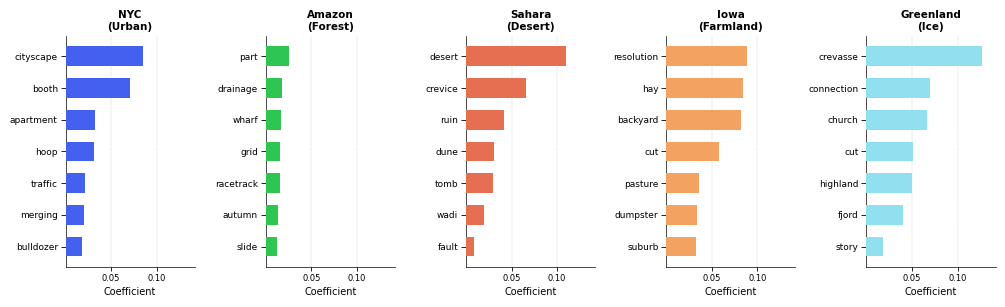

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 18,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 3,
    "pdf.fonttype": 42,   # embeds fonts for camera-ready
    "ps.fonttype": 42,
})

locations = {
    "NYC\n(Urban)":      ((40.7128, -74.0060), "#4361ee"),
    "Amazon\n(Forest)":   ((-3.4653, -62.2159), "#2dc653"),
    "Sahara\n(Desert)":   ((22.2348,   7.9586), "#e76f51"),
    "Iowa\n(Farmland)":   ((41.8780,  -93.0977), "#f4a261"),
    "Greenland\n(Ice)":   ((72.0000,  -40.0000), "#90e0ef"),
}

top_k = 7
fig, axes = plt.subplots(1, len(locations), figsize=(14.0, 3.0),  # ~textwidth for two-column paper
                          gridspec_kw={"wspace": 0.55})

all_vals = []
for name, ((lat, lon), color) in locations.items():
    latlon = torch.tensor([[lat, lon]], dtype=torch.float32, device="cuda:0")
    with torch.no_grad():
        w, _ = splice_model.encode_image(latlon)
    pairs = sorted(zip(concepts, w[0].tolist()), key=lambda x: -x[1])
    pairs = [(c, v) for c, v in pairs if v > 0][:top_k]
    all_vals.extend([v for _, v in pairs])
xmax = max(all_vals) * 1.12

for ax, (name, ((lat, lon), color)) in zip(axes, locations.items()):
    latlon = torch.tensor([[lat, lon]], dtype=torch.float32, device="cuda:0")
    with torch.no_grad():
        w, _ = splice_model.encode_image(latlon)
    pairs = sorted(zip(concepts, w[0].tolist()), key=lambda x: -x[1])
    pairs = [(c, v) for c, v in pairs if v > 0][:top_k]
    if not pairs:
        continue
    labels, vals = zip(*pairs)
    y = np.arange(len(vals))

    ax.barh(y, vals, height=0.62, color=color, edgecolor="none", zorder=3)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=6.5)
    ax.invert_yaxis()
    ax.set_xlim(0, xmax)
    ax.set_xlabel("Coefficient", fontsize=7, labelpad=3)
    ax.set_title(name, fontsize=7.5, fontweight="bold", pad=4, linespacing=1.3)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(3, prune="both"))
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax.tick_params(axis="x", labelsize=6, pad=2)
    ax.tick_params(axis="y", pad=2)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_linewidth(0.5)
    ax.grid(axis="x", linewidth=0.35, linestyle="--", color="#cccccc", zorder=0)
    ax.set_axisbelow(True)

plt.savefig("splice_decomposition.pdf", bbox_inches="tight", dpi=300)
plt.show()